Perform Linear Regression

In [52]:
"""Importing Libraries"""
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

#Reading csv file
file_path = "data_scaling_skewed_data.csv"
df = pd.read_csv(file_path)

df.head()

,Student_ID,Study_Hours,Age,Attendance,Family_Income,Internet_Usage_Hours,Exam_Score
0,1,4.79,25,68.22,26401.83,5.13,68.46
1,2,2.99,25,72.62,29899.43,10.14,58.53
2,3,2.76,24,87.15,84956.82,6.63,50.72
3,4,2.76,20,87.14,15797.16,0.99,72.44
4,5,9.30,18,87.15,44019.48,2.10,60.92


In [2]:
df.shape

(100, 7)

In [3]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 7 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Student_ID            100 non-null    int64  
 1   Study_Hours           100 non-null    float64
 2   Age                   100 non-null    int64  
 3   Attendance            97 non-null     float64
 4   Family_Income         100 non-null    float64
 5   Internet_Usage_Hours  98 non-null     float64
 6   Exam_Score            100 non-null    float64
dtypes: float64(5), int64(2)
memory usage: 5.6 KB


,Student_ID,Study_Hours,Age,Attendance,Family_Income,Internet_Usage_Hours,Exam_Score
count,100.000000,100.000000,100.000000,97.000000,100.000000,98.000000,100.000000
mean,50.500000,3.838400,21.670000,81.819588,40416.447600,2.971837,67.884100
std,29.011492,2.453124,2.395513,9.957090,37941.665524,2.842141,11.554282
min,1.000000,0.430000,18.000000,49.590000,3977.840000,0.050000,40.340000
25%,25.750000,2.180000,20.000000,75.380000,15954.600000,0.765000,59.675000
50%,50.500000,3.395000,22.000000,82.640000,27459.915000,2.165000,67.640000
75%,75.250000,4.810000,24.000000,88.620000,47944.172500,3.900000,76.387500
max,100.000000,14.600000,25.000000,100.000000,193072.810000,13.700000,94.900000


Checking Missing Values

In [4]:
df.isna().sum()

Student_ID              0
Study_Hours             0
Age                     0
Attendance              3
Family_Income           0
Internet_Usage_Hours    2
Exam_Score              0
dtype: int64

In [5]:
df["Attendance"] = df["Attendance"].fillna(
    df["Attendance"].median()
)

In [6]:
df["Internet_Usage_Hours"] = df["Internet_Usage_Hours"].fillna(
    df["Internet_Usage_Hours"].median()
)

In [7]:
df.isnull().sum()

Student_ID              0
Study_Hours             0
Age                     0
Attendance              0
Family_Income           0
Internet_Usage_Hours    0
Exam_Score              0
dtype: int64

Checking if duplicated values exists

In [8]:
df.duplicated().sum()

np.int64(0)

In [28]:
df = df.drop_duplicates()

In [10]:
df = df.drop(columns=["Student_ID"])
df.head()

,Study_Hours,Age,Attendance,Family_Income,Internet_Usage_Hours,Exam_Score
0,4.79,25,68.22,26401.83,5.13,68.46
1,2.99,25,72.62,29899.43,10.14,58.53
2,2.76,24,87.15,84956.82,6.63,50.72
3,2.76,20,87.14,15797.16,0.99,72.44
4,9.30,18,87.15,44019.48,2.10,60.92


Exploratory Data Analysis

<Figure size 800x500 with 0 Axes>

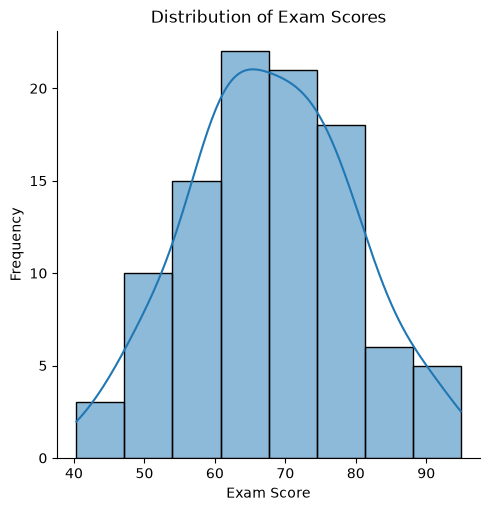

In [31]:
plt.figure(figsize=(8, 5))

sns.displot(x=df["Exam_Score"], kde=True)

plt.xlabel("Exam Score")
plt.ylabel("Frequency")
plt.title("Distribution of Exam Scores")

plt.show()

Check Outliers

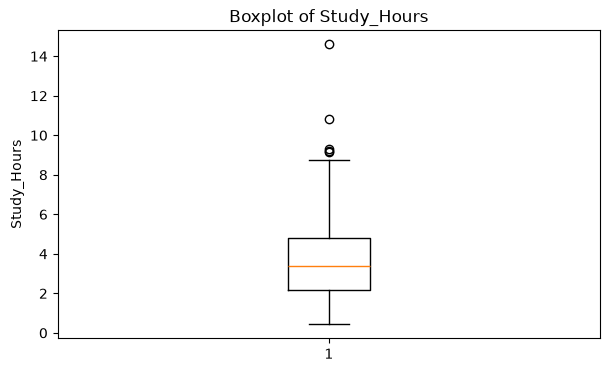

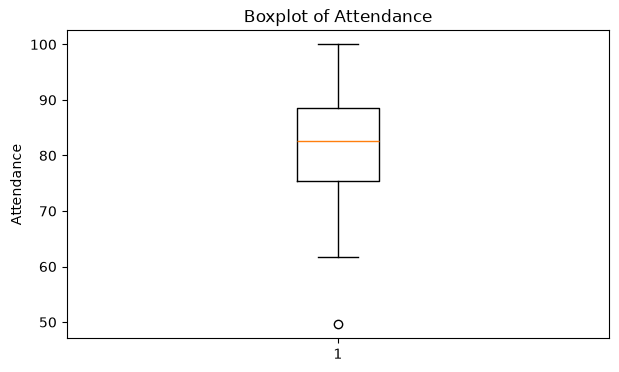

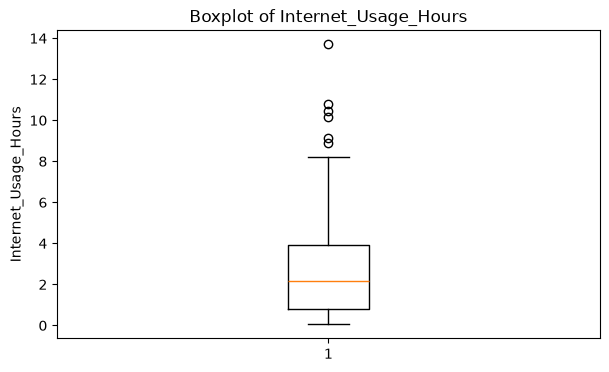

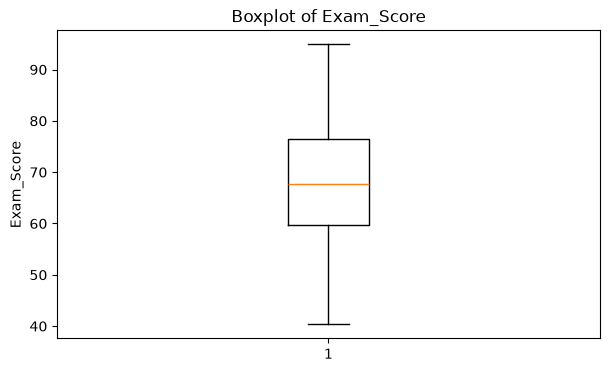

In [35]:
columns_to_check = [
    "Study_Hours",
    "Attendance",
    "Internet_Usage_Hours",
    "Exam_Score"
]

for column in columns_to_check:
    plt.figure(figsize=(7, 4))
    plt.boxplot(df[column])
    plt.title(f"Boxplot of {column}")
    plt.ylabel(column)

    plt.show()

Correlation Analysis

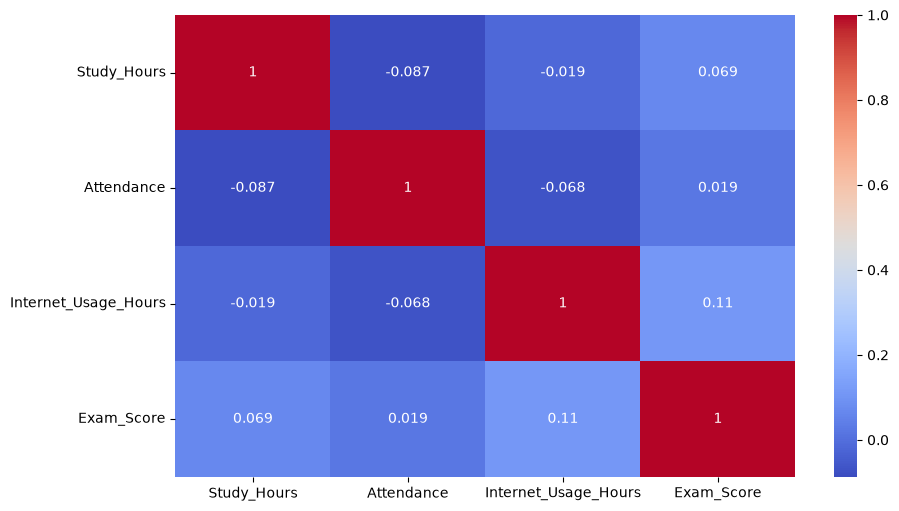

In [36]:
selected_columns = [
    "Study_Hours",
    "Attendance",
    "Internet_Usage_Hours",
    "Exam_Score"
]

correlation = df[selected_columns].corr()

plt.figure(figsize=(10, 6))
sns.heatmap(correlation,annot=True,cmap="coolwarm")
plt.show()

Feature and Target Selection

In [37]:
# Features / Independent Variables
X = df[[
    "Study_Hours",
    "Attendance",
    "Internet_Usage_Hours"
]]

# Target / Dependent Variable
y = df["Exam_Score"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (100, 3)
y shape: (100,)


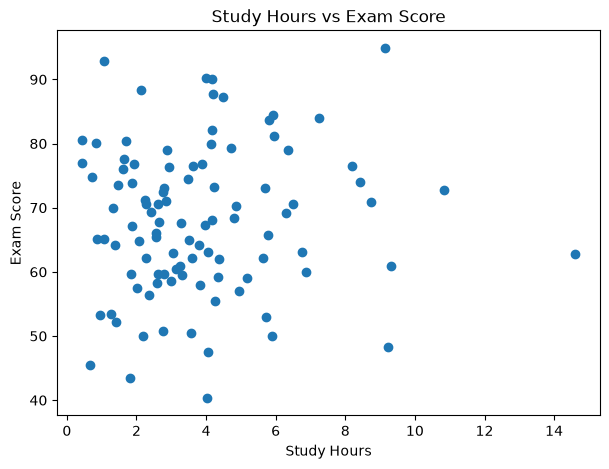

In [38]:
plt.figure(figsize=(7, 5))

plt.scatter(
    df["Study_Hours"],
    df["Exam_Score"]
)

plt.xlabel("Study Hours")
plt.ylabel("Exam Score")
plt.title("Study Hours vs Exam Score")

plt.show()

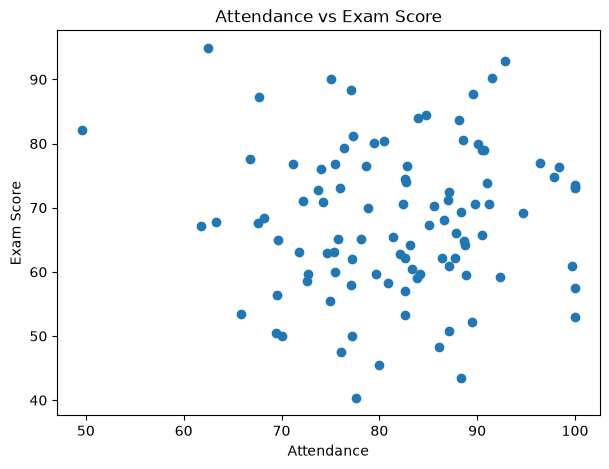

In [39]:
plt.figure(figsize=(7, 5))

plt.scatter(
    df["Attendance"],
    df["Exam_Score"]
)

plt.xlabel("Attendance")
plt.ylabel("Exam Score")
plt.title("Attendance vs Exam Score")

plt.show()

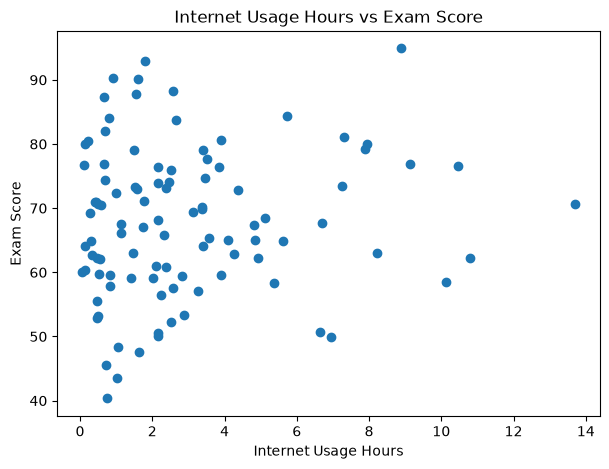

In [40]:
plt.figure(figsize=(7, 5))

plt.scatter(
    df["Internet_Usage_Hours"],
    df["Exam_Score"]
)

plt.xlabel("Internet Usage Hours")
plt.ylabel("Exam Score")
plt.title("Internet Usage Hours vs Exam Score")

plt.show()

Train-Test Split

In [41]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)


print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (80, 3)
X_test : (20, 3)
y_train: (80,)
y_test : (20,)


Linear Regression Model

In [43]:
from sklearn.linear_model import LinearRegression

model=LinearRegression()

Training the Linear Regression Model

In [44]:
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](3,)","[0.63,0.06,0.31]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](3,)","['Study_Hours','Attendance','Internet_Usage_Hours']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,60.15
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,3
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(3)


MODEL COEFFICIENTS

In [46]:
print("Intercept:", model.intercept_)

print("\nCoefficients:")
for feature, coefficient in zip(X.columns, model.coef_):
    print(f"{feature}: {coefficient}")

Intercept: 60.153940260154876

Coefficients:
Study_Hours: 0.6320829017178159
Attendance: 0.061006838879322844
Internet_Usage_Hours: 0.3130328416712469


Making Predictions

In [47]:
y_pred = model.predict(X_test)

print("Predictions:")
print(y_pred)

Predictions:
[67.49340143 67.56750155 66.50603577 71.56638841 69.02310819 68.57266102
 65.9525406  69.45646462 66.86624127 68.94936239 68.54050382 69.40733524
 68.87841311 69.17335921 69.50745987 72.00642622 66.13582702 68.6280225
 70.33447571 68.05590832]


Compare Actual vs Predicted data

In [48]:
compare = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

display(compare)

,Actual,Predicted
0,66.09,67.493401
1,55.47,67.567502
2,71.04,66.506036
3,48.34,71.566388
4,60.84,69.023108
5,79.02,68.572661
6,53.22,65.952541
7,73.48,69.456465
8,69.90,66.866241
9,68.46,68.949362


Error Validation Technique

In [49]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

Mean Absolute Error

In [ ]:
mae=mean_absolute_error(y_test,y_pred)
print("MAE:",mae)

MAE: 6.342072320587134


Mean Squared Error

In [51]:
mse=mean_squared_error(y_test,y_pred)
print("MSE:",mse)

MSE: 71.58251998846549


Root Mean Squared Error

In [53]:
rmse=np.sqrt(mse)
print("RMSE:", rmse)

RMSE: 8.46064536477363


R² SCORE

In [54]:
r2=r2_score(y_test,y_pred)
print("R2:",r2)

R2: -0.23694606553288589


Adjusted R²

In [55]:
# Number of observations
n=X_test.shape[0]

# Number of predictors
p=X_test.shape[1]

adjusted_r2=1-((1-r2)*(n-1)/(n-p-1))
print("Adjusted R²:", adjusted_r2)

Adjusted R²: -0.468873452820302
